In [1]:
from mdcrow import MDCrow
from langchain.callbacks import get_openai_callback
from datetime import datetime
import os 
import traceback

In [2]:
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '../'))
sys.path.append(parent_dir)
from robustness_prompts import get_prompt # noqa: E402

prompt_8_natural = get_prompt("natural", 8)

prompt_8_natural

'Simulate 1LYZ for 1ps at 300 K and for 1ps at 400K. Report the secondary structure assignments of the downloaded PDB structure and any known binding or active sites. Compute the RMSD, SASA, and radius of gyration of the 300K simulation.'

In [3]:
llm_model = "gpt-4-1106-preview"
tools = "all"

In [4]:
agent = MDCrow(
    agent_type="Structured", 
    model=llm_model, 
    top_k_tools=tools, 
    use_memory=False,
    streaming=False,
    verbose=True,
)
with get_openai_callback() as cb:
    chat_start = datetime.now()
    try:
        response = agent.run(prompt_8_natural, callbacks=[cb])
        print(response)
    except Exception as e:
        exc_type, exc_value, exc_traceback = sys.exc_info()
        print(f'{type(e).__name__}:{e}')
        print("".join(traceback.format_exception(exc_type, exc_value, exc_traceback)))
    chat_end = datetime.now()
    total_runtime = (chat_end - chat_start).total_seconds()
    print(cb)
    print(f"Total runtime: {total_runtime:.2f}s")



> Entering new AgentExecutor chain...


Thought: The task involves multiple steps: simulating the protein 1LYZ at two different temperatures, reporting secondary structure assignments, identifying any known binding or active sites, and computing RMSD, SASA, and radius of gyration for the 300K simulation. The first step is to download the PDB structure of 1LYZ to use as the starting point for the simulations.

Action:
```
{
    "action": "PDBFileDownloader",
    "action_input": {
        "query": "1LYZ"
    }
}
```

PDB file found with this ID: 1LYZ

Observation: Succeeded. Downloaded the PDB file:1LYZ_213816
Thought:

Now that the PDB file for 1LYZ has been downloaded, the next step is to set up and run the molecular dynamics simulations at 300K and 400K. Since the simulations are to be run for 1 picosecond (ps) each, I will need to specify the simulation parameters accordingly. I will use the SetUpandRunFunction tool to perform the simulations. The forcefield files will be chosen based on common practice for protein simulations, such as AMBER or CHARMM. After running the simulations, I will proceed with the secondary structure assignment and identification of known binding or active sites.

Action:
```
{
    "action": "SetUpandRunFunction",
    "action_input": {
        "pdb_id": "1LYZ_213816",
        "forcefield_files": ["amber14-all.xml", "amber14/tip3p.xml"],
        "save": true,
        "system_params": {
            "nonbondedMethod": "PME",
            "nonbondedCutoff": "1 * nanometers",
            "constraints": "HBonds",
            "rigidWater": true,
            "solvate": true
      

The previous attempt to run the simulation failed because the constraintTolerance parameter was not specified, which is required when rigidWater is set to True. I need to correct this and try running the simulation again. This time, I will include the constraintTolerance parameter in the system_params. Additionally, I will set up two simulations, one at 300K and another at 400K, as requested.

Action:
```
{
    "action": "SetUpandRunFunction",
    "action_input": {
        "pdb_id": "1LYZ_213816",
        "forcefield_files": ["amber14-all.xml", "amber14/tip3p.xml"],
        "save": true,
        "system_params": {
            "nonbondedMethod": "PME",
            "nonbondedCutoff": "1 * nanometers",
            "constraints": "HBonds",
            "rigidWater": true,
            "constraintTolerance": 0.00001,
            "solvate": true
        },
        "integrator_params": {
            "integrator_type": "LangevinMiddle",
            "Temperature": "300 * kelvin",
            "Fri

About to create system...
Attempts at creating system: 0/3
Error adding solvent ValueError – No template found for residue 1 (LYS).  The set of atoms is similar to HID, but it is missing 8 atoms.  For more information, see https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions#template
Residue code: LYS
Residue code not in solvent list. Adding forcefield                         not supported.

Observation: Failed. No template found for residue 1 (LYS).  The set of atoms is similar to HID, but it is missing 8 atoms.  For more information, see https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions#templateThis were the inputs {'pdb_id': '1LYZ_213816', 'forcefield_files': ['amber14-all.xml', 'amber14/tip3p.xml'], 'save': True, 'system_params': {'nonbondedMethod': 'PME', 'nonbondedCutoff': '1 * nanometers', 'constraints': 'HBonds', 'rigidWater': True, 'constraintTolerance': 1e-05, 'solvate': True}, 'integrator_params': {'integrator_type': 'LangevinMiddle', 'Temperature'

...

SASA plot saved to FIG_sasa_sim0_213850_20251222_223330.png

Observation: Succeeded. SASA values computed and saved with File ID sasa_sim0_213850. SASA analysis completed. Saved the plot with plot ID fig0_223330. 
Thought:

The SASA for the 300K simulation has been successfully computed. Now, I will calculate the radius of gyration for the 300K simulation using the RadiusofGyrationTool.

Action:
```
{
    "action": "RadiusofGyrationTool",
    "action_input": {
        "traj_file": "rec0_213856",
        "top_file": "top_sim0_213850"
    }
}
```

plot_name:  FIG_rgy_rec0_213856_20251222_223336.png
plot_path /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_11/figures/FIG_rgy_rec0_213856_20251222_223336.png

Observation: Succeeded. Radii of gyration saved to /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_11/figures/radii_of_gyration_rec0_213856.csv with id rgy_rec0_213856.Plot saved as: FIG_rgy_rec0_213856_20251222_223336.png with plot ID fig0_223336Average radius of gyration: 3.44 nm
Thought:

Question: What is the final report for the molecular dynamics simulations of protein 1LYZ?

Thought: The final report should include the results from the simulations at 300K and 400K, the secondary structure assignments, the identification of active sites, and the computed values for RMSD, SASA, and radius of gyration for the 300K simulation.

Action:
```
{
  "action": "Final Answer",
  "action_input": "The molecular dynamics simulations of protein 1LYZ were successfully performed at 300K and 400K. The secondary structure assignments for the first frame of the 300K simulation indicated 49 residues in helix, 14 residues in strand, and 66 residues in coil. Active sites were identified at residues 53 and 71, with no known binding sites or other relevant sites reported. The RMSD for the 300K simulation was calculated and saved with file ID rmsd_213850. The Solvent Accessible Surface Area (SASA) for the 300K simulation was computed and saved with File ID sasa_sim0_213850. The average radius

<Figure size 640x480 with 0 Axes>

In [3]:
registry = agent.path_registry
print(registry.list_path_names_and_descriptions().replace(",", "\n"))

Files found in registry: 1LYZ_213816: PDB file downloaded from RSCB
 PDBFile ID: 1LYZ_213816
 1LYZ_213841: Cleaned File:  Removed Heterogens
 and Water Removed.  Replaced Nonstandard Residues. Added Hydrogens at pH 7.0. Missing Atoms added and nonstandard residues replaced. 
 top_sim0_213850: Initial positions for simulation sim0_213850
 sim0_213850: Basic Simulation of Protein 1LYZ_213841
 rec0_213856: Simulation trajectory for protein 1LYZ_213841 and simulation sim0_213850
 rec1_213856: Simulation state log for protein 1LYZ_213841 and simulation sim0_213850
 rec2_213856: Simulation pdb frames for protein 1LYZ_213841 and simulation sim0_213850
 top_sim0_215312: Initial positions for simulation sim0_215312
 sim0_215312: Basic Simulation of Protein 1LYZ_213841
 rec0_215318: Simulation trajectory for protein 1LYZ_213841 and simulation sim0_215312
 rec1_215318: Simulation state log for protein 1LYZ_213841 and simulation sim0_215312
 rec2_215318: Simulation pdb frames for protein 1LYZ_2138

In [6]:
print('ckpt_dir:',os.path.basename(agent.path_registry.ckpt_dir))

ckpt_dir: ckpt_11


In [4]:
# make sure pdb was downloaded
assert os.path.exists(registry.get_mapped_path("1LYZ_213816"))

In [5]:
# make sure dssp was computed correctly
from mdcrow.tools.base_tools import ComputeDSSP

dssp = ComputeDSSP(registry)
dssp._run(traj_file= "1LYZ_213816", target_frames="first")

"{'residues in helix': 50, 'residues in strand': 14, 'residues in coil': 65, 'residues not assigned, not a protein residue': 101}"

In [9]:
# make sure the sites were found
from mdcrow.tools.base_tools import GetAllKnownSites

get_all_known_sites = GetAllKnownSites()
get_all_known_sites._run(query="1LYZ", primary_accession="")

"Active Sites: [{'start': 53, 'start_modifier': 'EXACT', 'end': 53, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}, {'start': 71, 'start_modifier': 'EXACT', 'end': 71, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}]\nNo known binding sites.\nNo other relevant sites."

In [6]:
# make sure trajectory and topology exist
traj_path_1 = registry.get_mapped_path("rec0_213856")
top_path_1 = registry.get_mapped_path("top_sim0_213850")

assert os.path.exists(traj_path_1)
assert os.path.exists(top_path_1)

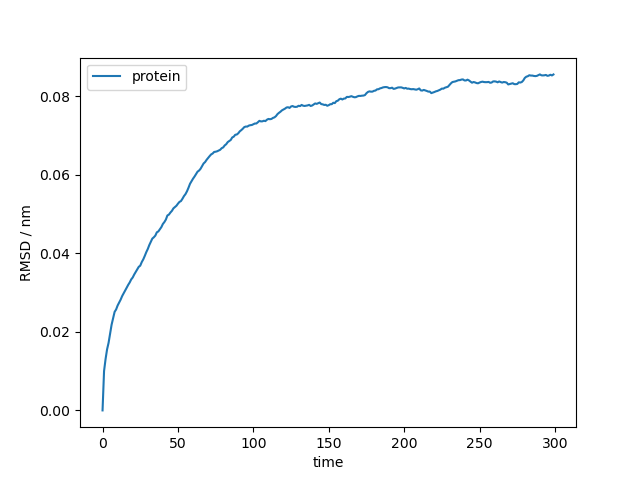

In [7]:
# make sure rmsd plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_220838'))

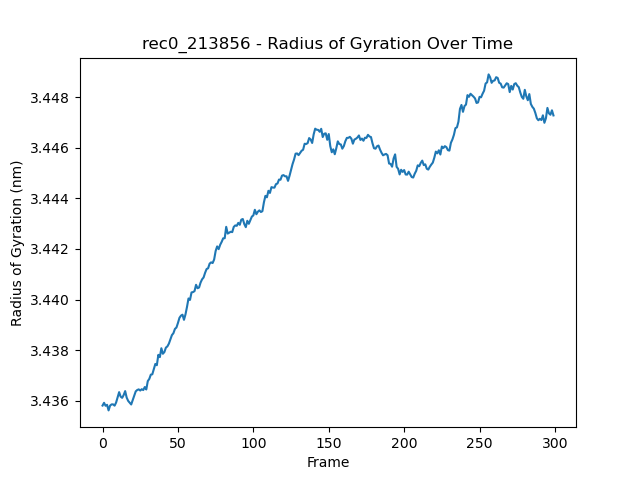

In [9]:
# make sure rgy plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_223336'))

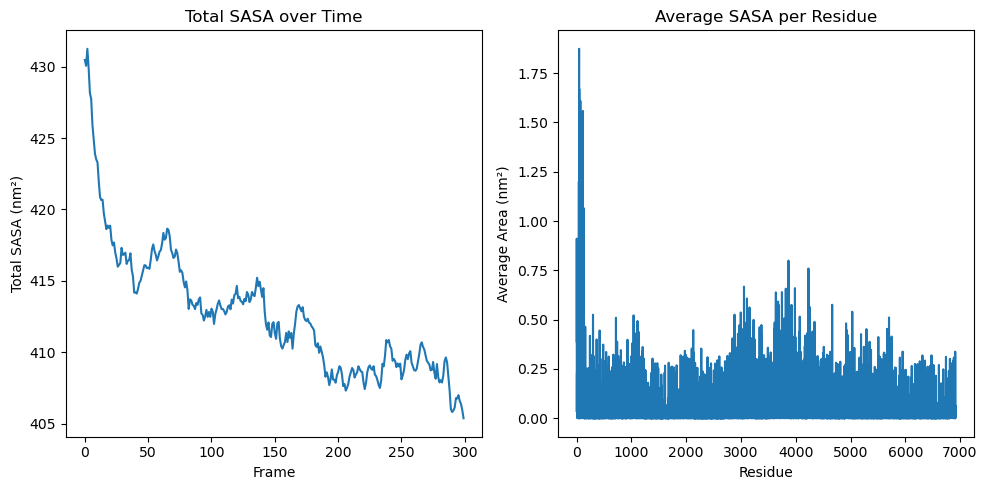

In [8]:
# make sure sasa plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_223330'))

In [10]:
# make sure trajectory and topology exist (sim2)
traj_path_2 = registry.get_mapped_path("rec0_215318")
top_path_2 = registry.get_mapped_path("top_sim0_215312")

assert os.path.exists(traj_path_2)
assert os.path.exists(top_path_2)